<a href="https://colab.research.google.com/github/ahmadazhar22-11-5175/Analisis-Faktor-Risiko-Obesitas-dan-Prediksi-dengan-Decision-Tree-Studi-Kasus-Dataset-Obesitas/blob/kuy/Analisis_Faktor_Risiko_Obesitas_dan_Prediksi_dengan_Decision_Tree_Studi_Kasus_Dataset_Obesitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analisis Faktor Risiko Obesitas dan Prediksi dengan Decision Tree: Studi Kasus Dataset Obesitas**

- Nama  : Ahmad Azhar Nurwahid
- Nim   : 22.11.5175
- Kelas : Big Data And Data Mining 4

# **Imports Libry**

In [1]:
!pip install scikit-plot

In [2]:
%matplotlib inline

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.interpolate import interp1d

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.cluster import KMeans

# **Load data**

In [4]:
obesity_data = pd.read_csv("/content/Obesity prediction.csv")

In [5]:
obesity_data.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [6]:
obesity_data.shape

(2111, 17)

# **Exploratory Data Analysis**

In [7]:
obesity_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

# **Explore Features**

In [8]:
def count_values(dataset, cat_variable, order = None):

    ax = sns.countplot(x = cat_variable, data = dataset, palette = "Blues_r", order = order)
    for p in ax.patches:
        ax.annotate(f"\n{p.get_height()}", (p.get_x()+0.2, p.get_height()),
                    ha = "center", va = "top", color = "white", size = 10)

    plt.title(f"Number of items in each {cat_variable} category")
    plt.show()

# **Gender**

<ipython-input-8-724bc170bd48>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = cat_variable, data = dataset, palette = "Blues_r", order = order)


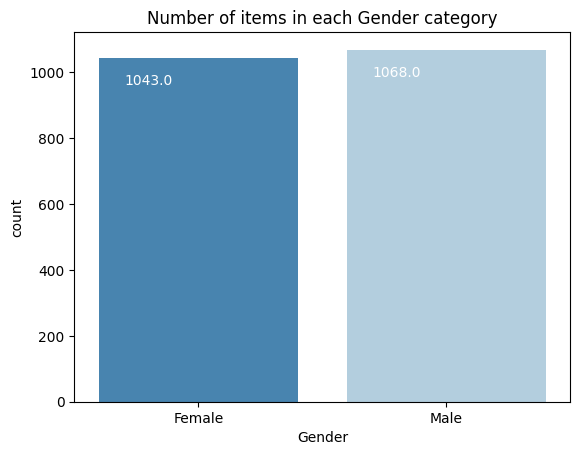

In [9]:
count_values(obesity_data, "Gender")

# **Age**

In [10]:
def plot_distribution(dataset, feature):

    plt.hist(dataset[feature], bins = "fd")

    plt.axvline(dataset[feature].mean(), color = "red", label = "mean")
    plt.axvline(dataset[feature].median(), color = "orange", label = "median")

    plt.xlabel(f"{feature}")
    plt.ylabel("Count")
    plt.legend()
    plt.title(f"Distribution of values in {feature}")
    plt.show()

In [11]:
obesity_data["Age"].describe()

,Age
count,2111.000000
mean,24.312600
std,6.345968
min,14.000000
25%,19.947192
50%,22.777890
75%,26.000000
max,61.000000


In [12]:
obesity_data["Age"].median()

22.77789

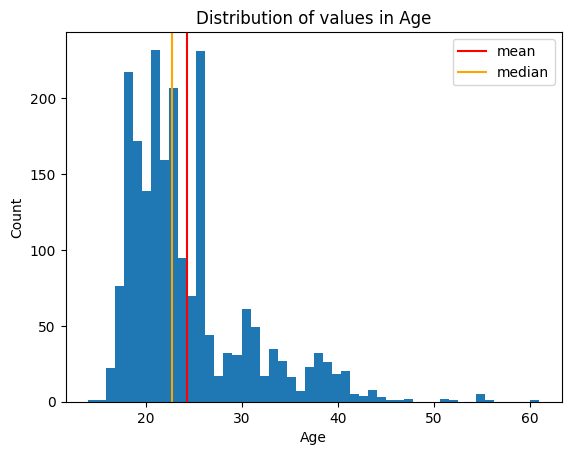

In [13]:
plot_distribution(obesity_data, "Age")

# **Height**

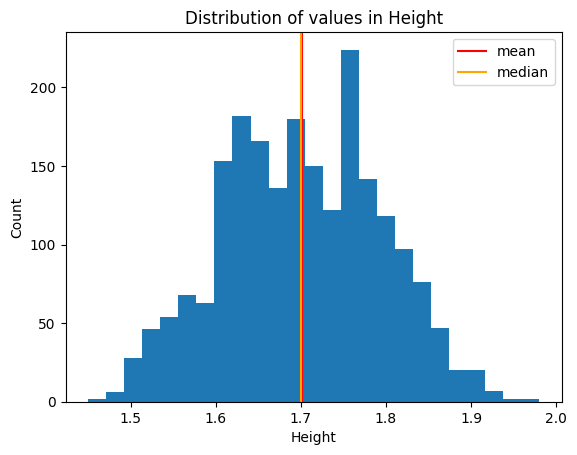

In [14]:
plot_distribution(obesity_data, "Height")

# **Weight**

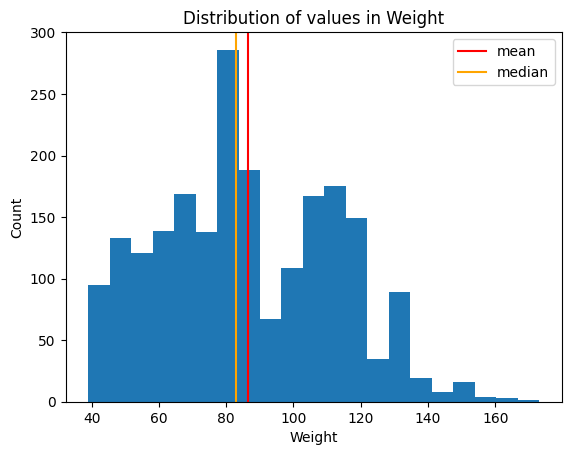

In [15]:
plot_distribution(obesity_data, "Weight")

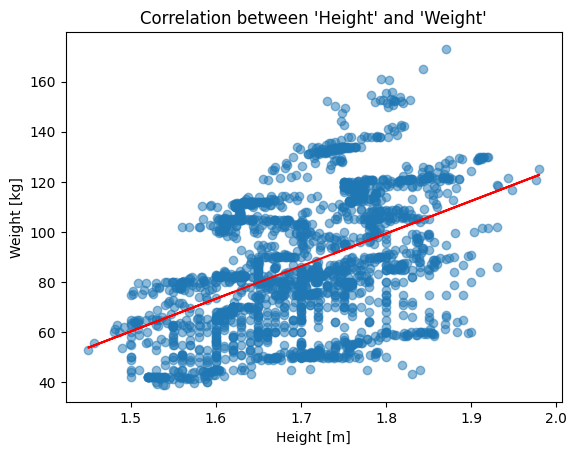

In [16]:
plt.scatter(obesity_data["Height"], obesity_data["Weight"], alpha = 0.5)
m, b = np.polyfit(obesity_data["Height"], obesity_data["Weight"], 1)
plt.plot(obesity_data["Height"], m * obesity_data["Height"] + b, color = "red")

plt.xlabel("Height [m]")
plt.ylabel("Weight [kg]")
plt.title("Correlation between 'Height' and 'Weight'")
plt.show()

# **Does overweight run in the family?**

<ipython-input-8-724bc170bd48>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = cat_variable, data = dataset, palette = "Blues_r", order = order)


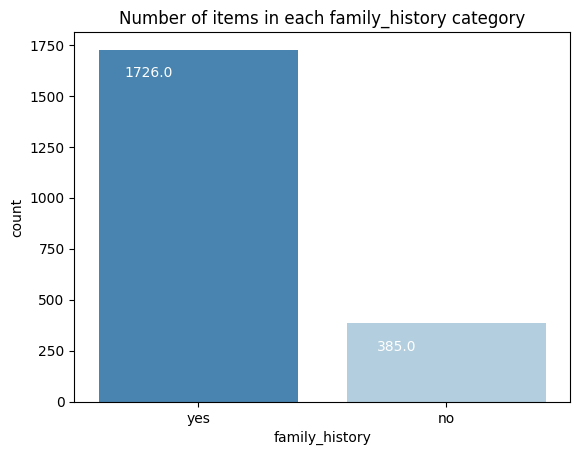

In [17]:
count_values(obesity_data, "family_history")

# **Consumption of high caloric food**

<ipython-input-8-724bc170bd48>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = cat_variable, data = dataset, palette = "Blues_r", order = order)


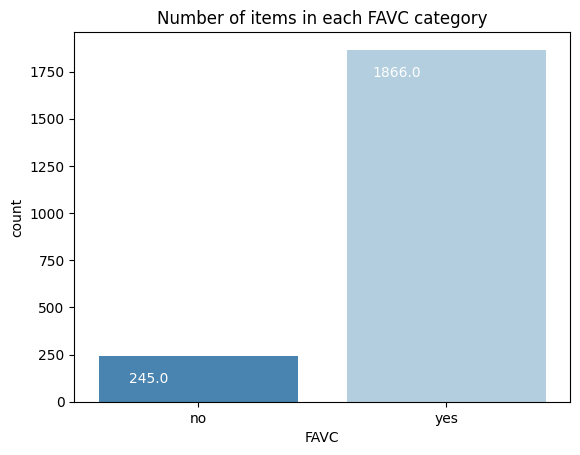

In [18]:
count_values(obesity_data, "FAVC")

# **Consumption of vegetables**

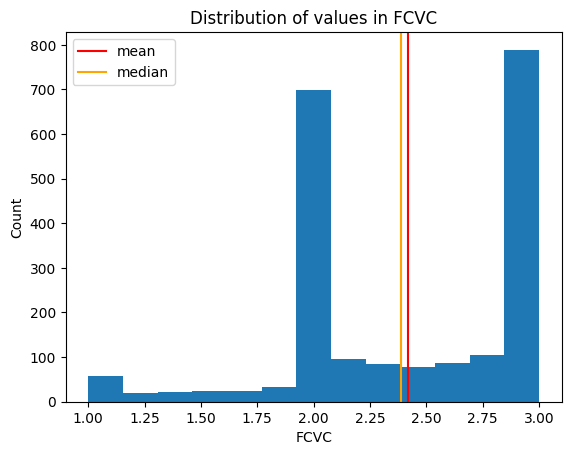

In [19]:
plot_distribution(obesity_data, "FCVC")

# **Food between meals**

<ipython-input-8-724bc170bd48>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = cat_variable, data = dataset, palette = "Blues_r", order = order)


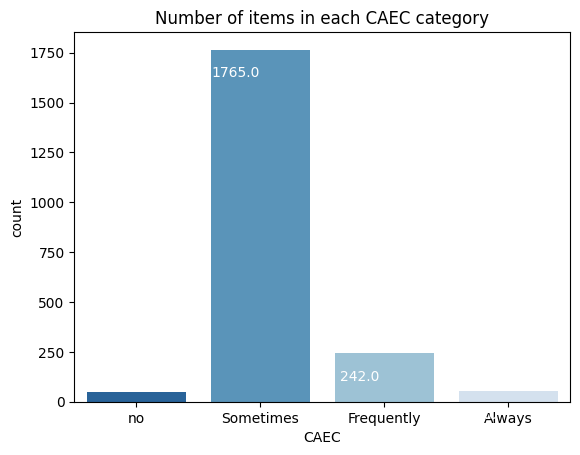

In [20]:
count_values(obesity_data, "CAEC", ["no", "Sometimes", "Frequently", "Always"])

# **Smoke**

<ipython-input-8-724bc170bd48>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = cat_variable, data = dataset, palette = "Blues_r", order = order)


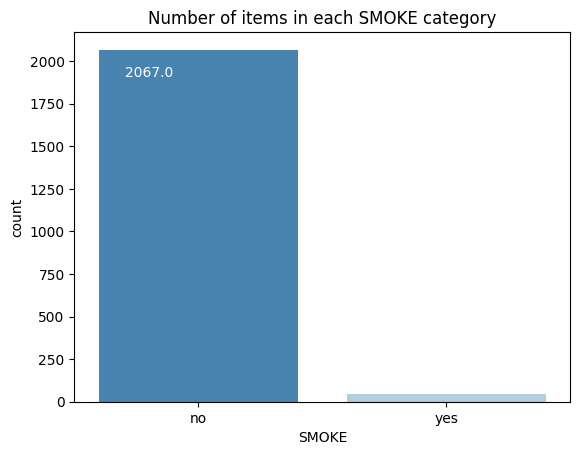

In [21]:
count_values(obesity_data, "SMOKE")

# **Drink water**

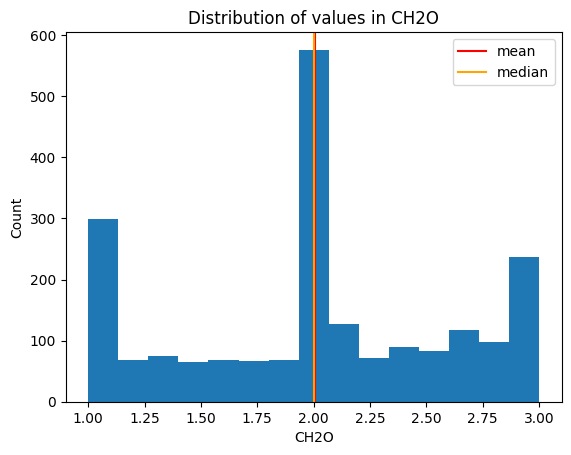

In [22]:
plot_distribution(obesity_data, "CH2O")

# **Monitor intake of calories**

<ipython-input-8-724bc170bd48>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = cat_variable, data = dataset, palette = "Blues_r", order = order)


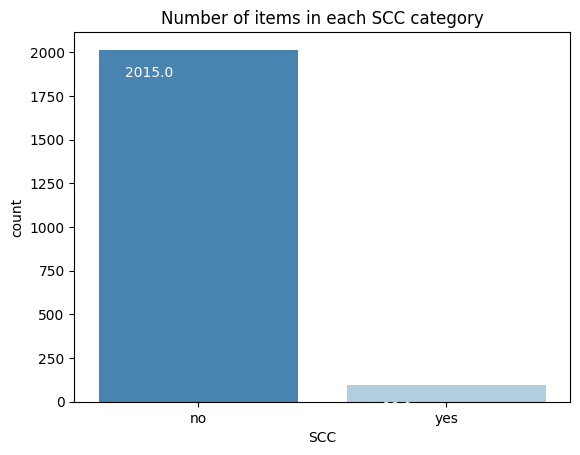

In [23]:
count_values(obesity_data, "SCC")

# **Physical activity**

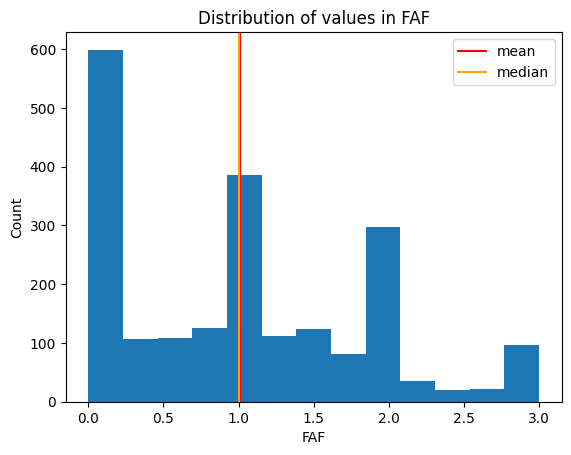

In [24]:
plot_distribution(obesity_data, "FAF")

# **Physical INactivity**

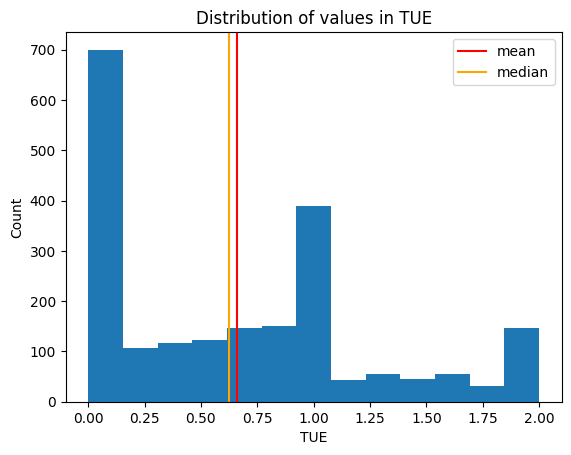

In [25]:
plot_distribution(obesity_data, "TUE")

# **Drink alcohol**

<ipython-input-8-724bc170bd48>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = cat_variable, data = dataset, palette = "Blues_r", order = order)


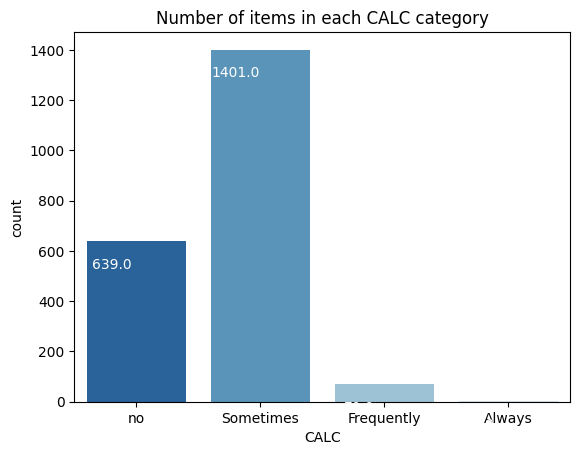

In [26]:
count_values(obesity_data, "CALC")

# **Transportation**

<ipython-input-8-724bc170bd48>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = cat_variable, data = dataset, palette = "Blues_r", order = order)


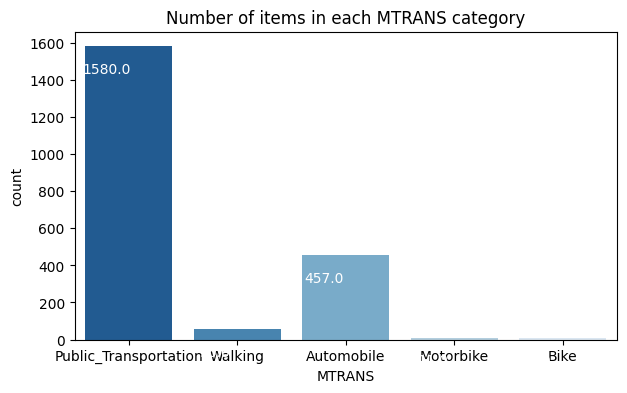

In [27]:
plt.figure(figsize = (7, 4))
count_values(obesity_data, "MTRANS")

# **Normal, Overweight or Obese?**

People, according to their Body mass index (BMI), are categorised as:

- Underweight if BMI < 18.5
- Normal if BMI 18.5 - 24.9
- Overweight if BMI 25.0 - 29.9
- Obesity I if BMI 30.0 - 34.9
- Obesity II if BMI 35.0 to 39.9
- Obesity III if BMI > 40

<ipython-input-8-724bc170bd48>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = cat_variable, data = dataset, palette = "Blues_r", order = order)


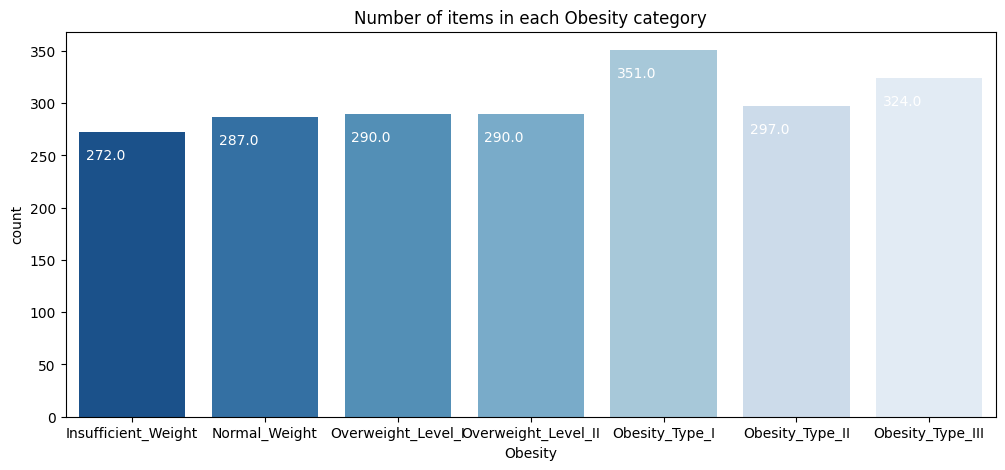

In [28]:
plt.figure(figsize = (12, 5))
count_values(obesity_data, "Obesity", ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"])

# **Overweight and Gender**

In [29]:
def cross_plot(dataset, lead_category, sup_category, order = None):

    sns.countplot(x = lead_category, hue = sup_category, data = dataset, order = order, palette = "Blues_r")

    plt.show()

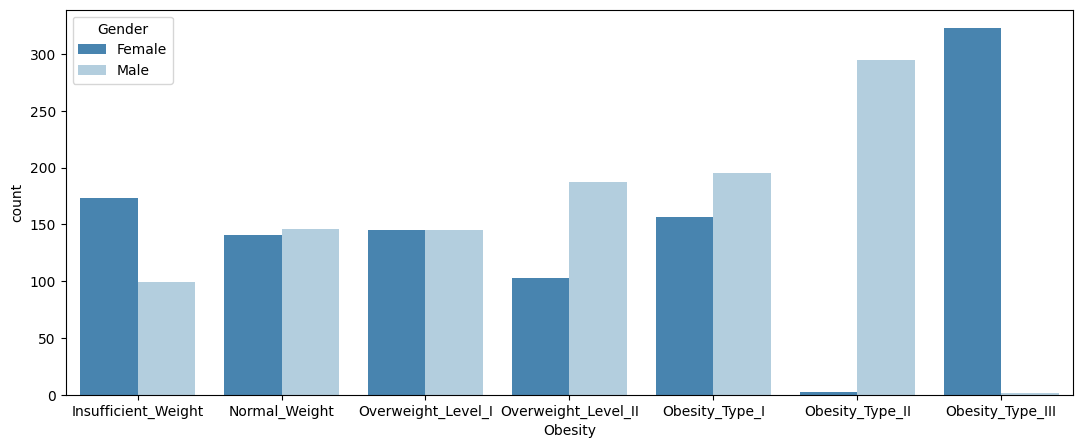

In [30]:
plt.figure(figsize = (13, 5))
cross_plot(obesity_data, "Obesity", "Gender", ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"])

# **Overweight and family history**

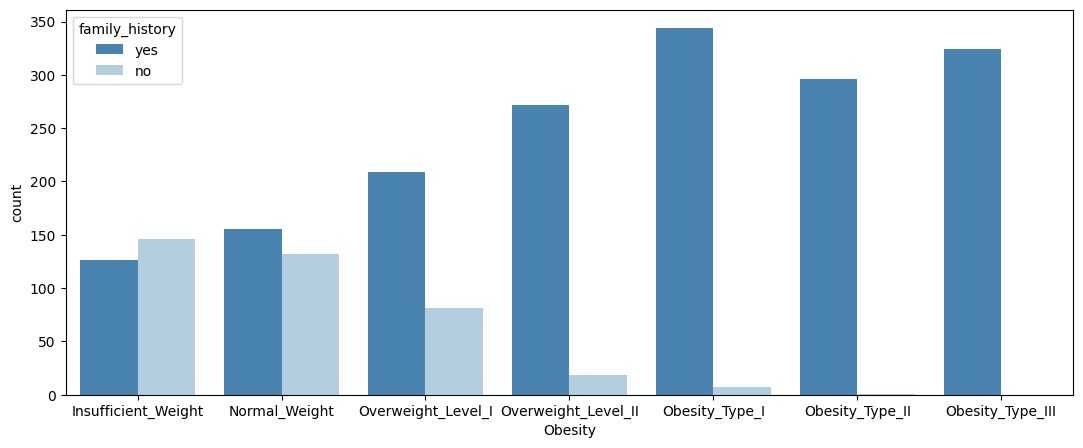

In [31]:
plt.figure(figsize = (13, 5))
cross_plot(obesity_data, "Obesity", "family_history", ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"])

# **Overweight and high calories food**

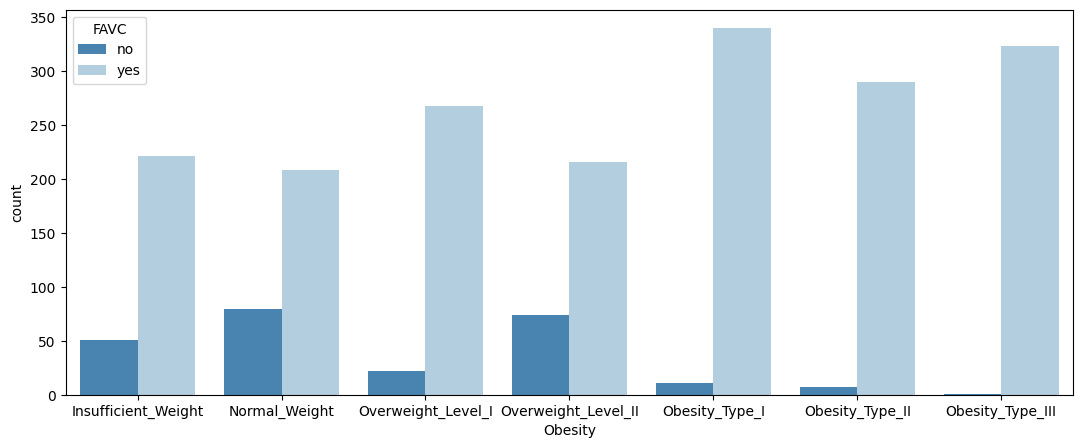

In [32]:
plt.figure(figsize = (13, 5))
cross_plot(obesity_data, "Obesity", "FAVC", ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"])

# **Overweight and food between meals**

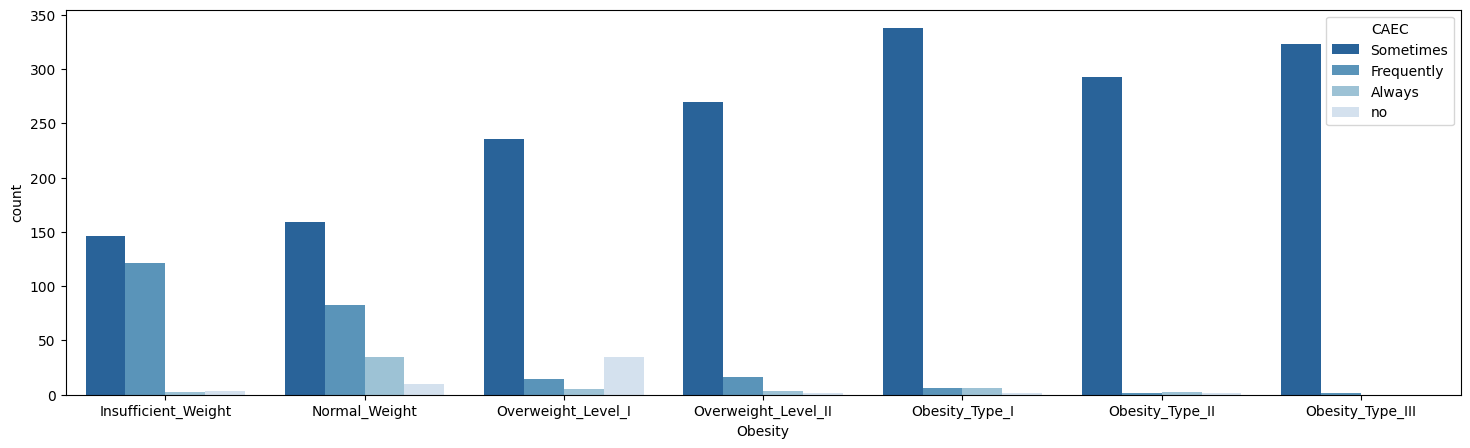

In [33]:
plt.figure(figsize = (18, 5))
cross_plot(obesity_data, "Obesity", "CAEC", ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"])

# **Overweight and smoking**

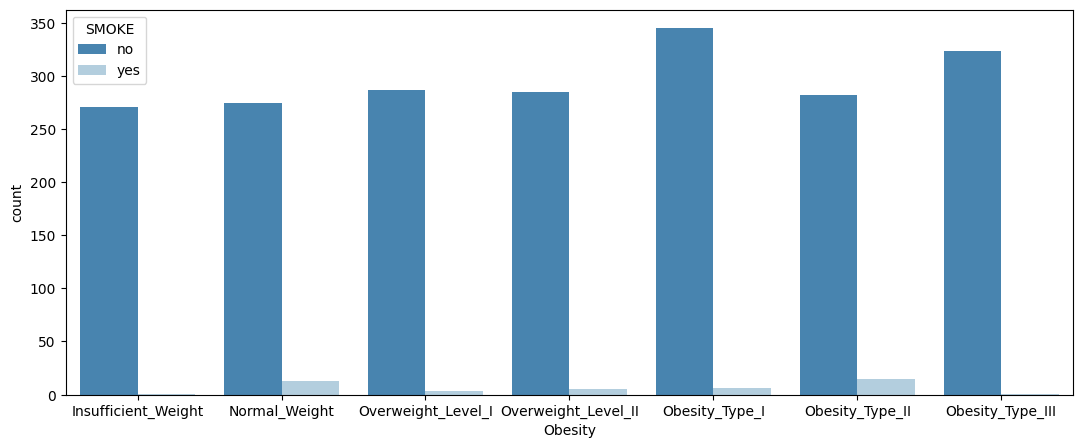

In [34]:
plt.figure(figsize = (13, 5))
cross_plot(obesity_data, "Obesity", "SMOKE", ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"])

# **Overweight and monitoring calories**

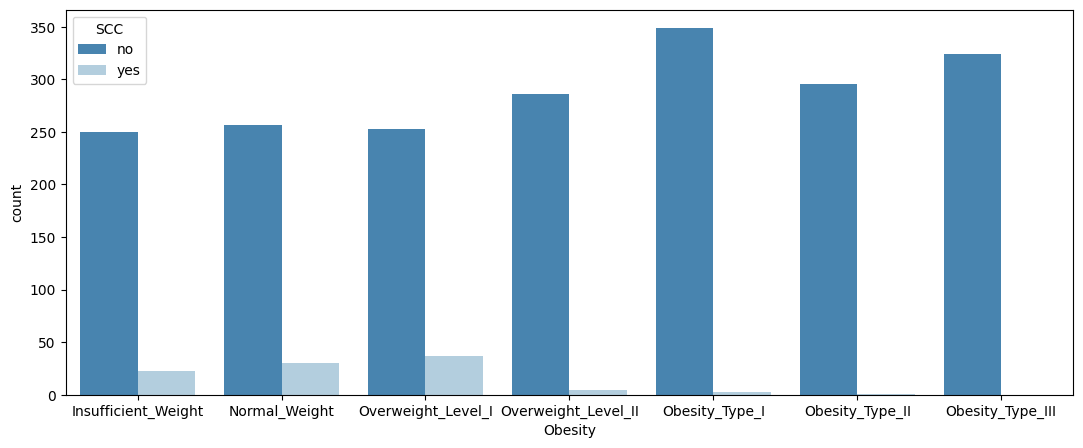

In [35]:
plt.figure(figsize = (13, 5))
cross_plot(obesity_data, "Obesity", "SCC", ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"])

# **Overweight and alcohol**

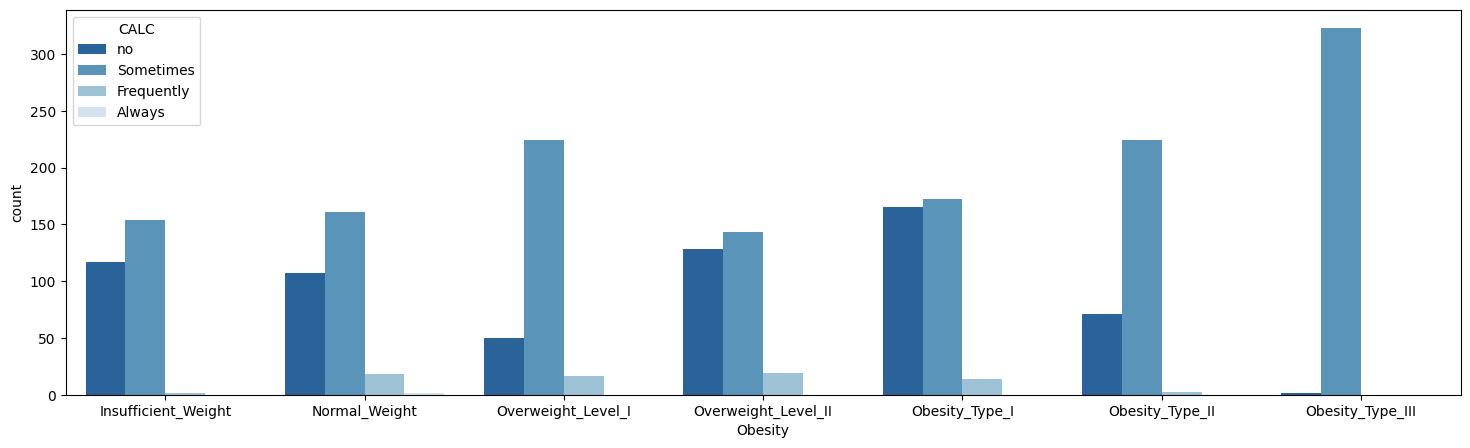

In [36]:
plt.figure(figsize = (18, 5))
cross_plot(obesity_data, "Obesity", "CALC", ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"])

# **Overweight and means of transport**

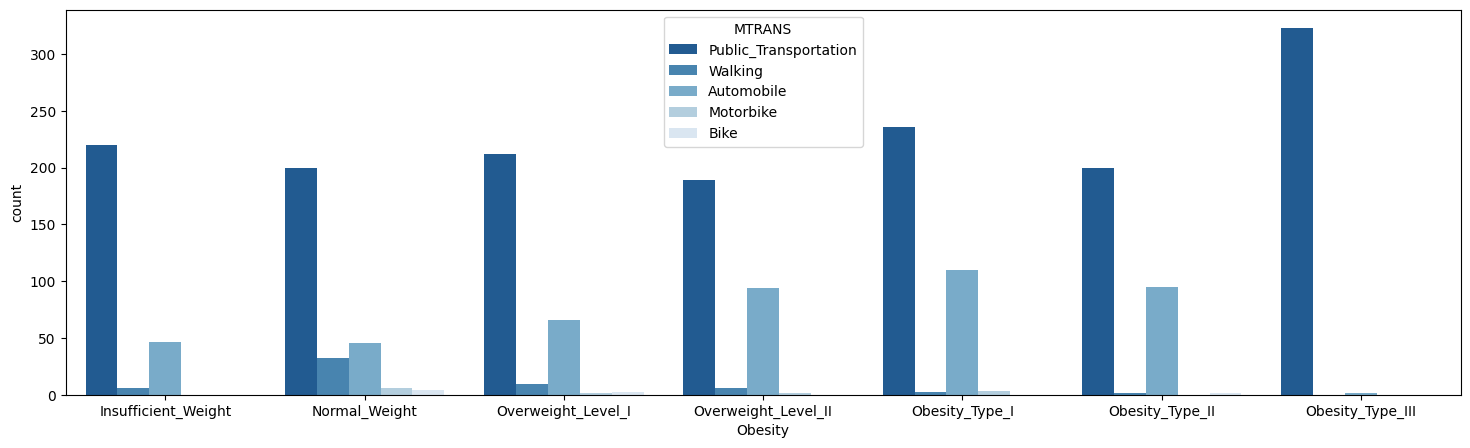

In [37]:
plt.figure(figsize = (18, 5))
cross_plot(obesity_data, "Obesity", "MTRANS", ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"])

# **Explore Statistics**

In [38]:
obesity_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FCVC,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


In [39]:
obesity_numeric = obesity_data[["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]]

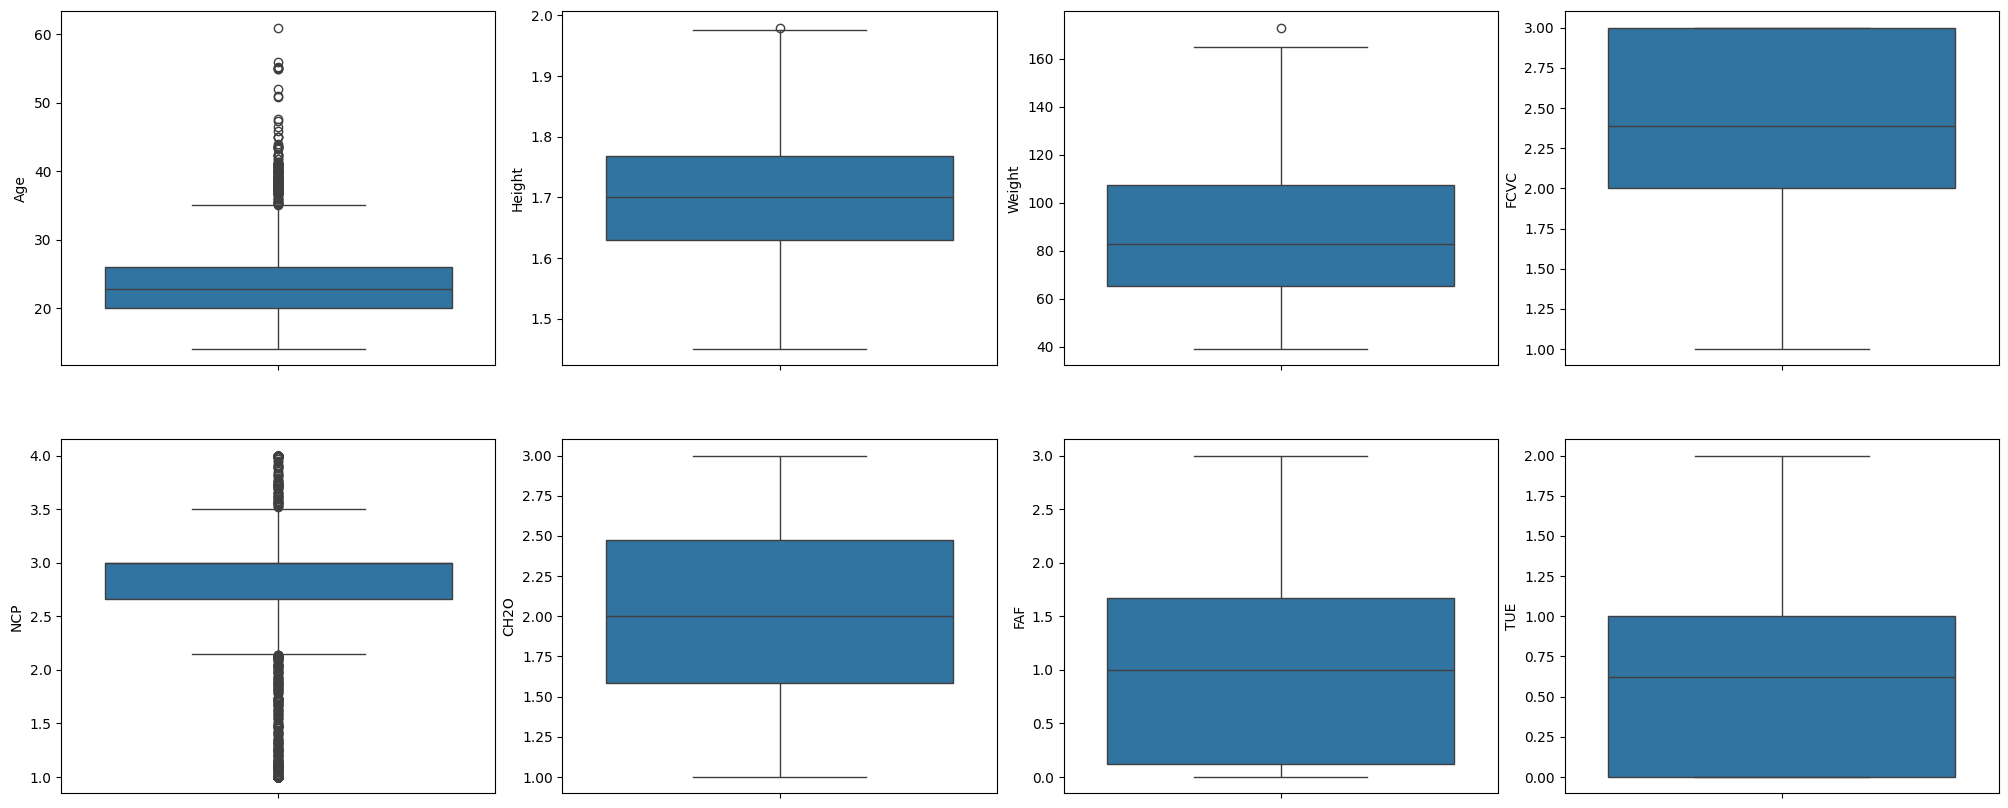

In [40]:
fig, axs = plt.subplots(ncols = 4, nrows = 2, figsize = (20, 8))
# fig.delaxes(axs[1][3])
idx = 0
axs = axs.flatten()
for k, v in obesity_numeric.items():
    sns.boxplot(y = k, data = obesity_numeric, ax = axs[idx])
    idx += 1
plt.tight_layout(pad = 0.4, w_pad = 0.5, h_pad = 5.0)

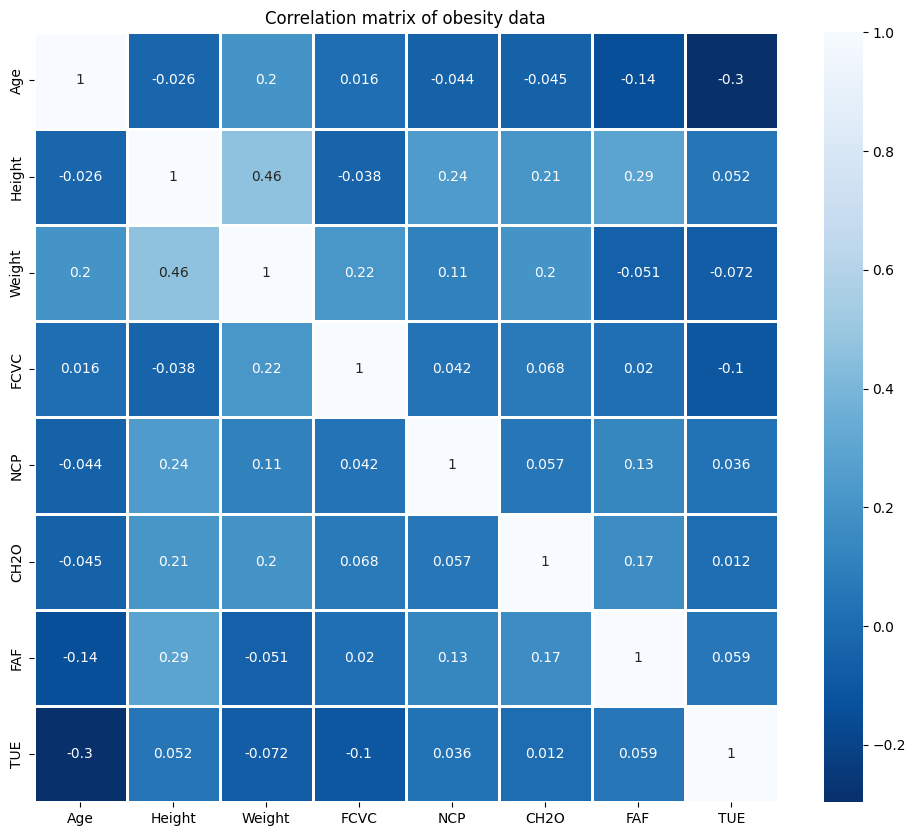

In [41]:
plt.figure(figsize = (12, 10))
sns.heatmap(obesity_data.select_dtypes(include=np.number).corr(),
           annot = True,
           cmap = "Blues_r",
           linewidths = 2,
           linecolor = "white")
plt.title("Correlation matrix of obesity data")
plt.show()

## **Data pre-processing**

# **Encoding Features**

In [42]:
obesity_dummies = pd.get_dummies(obesity_data[["Gender", "family_history", "FAVC", "CAEC", "SMOKE", "SCC", "CALC", "MTRANS"]])

In [43]:
obesity_lab = obesity_data[["Obesity"]]

In [44]:
obesity_concatenated = pd.concat([obesity_numeric, obesity_dummies, obesity_lab], axis = 1)

In [45]:
obesity_concatenated.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Female,Gender_Male,...,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,Obesity
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,True,False,...,False,False,False,True,False,False,False,True,False,Normal_Weight
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,True,False,...,False,False,True,False,False,False,False,True,False,Normal_Weight
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,False,True,...,False,True,False,False,False,False,False,True,False,Normal_Weight
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,False,True,...,False,True,False,False,False,False,False,False,True,Overweight_Level_I
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,False,True,...,False,False,True,False,False,False,False,True,False,Overweight_Level_II


# **Separate Features and Labels**

In [46]:
obesity_label = obesity_concatenated["Obesity"]
obesity_features = obesity_concatenated.drop("Obesity", axis = 1)

In [47]:
obesity_label

,Obesity
0,Normal_Weight
1,Normal_Weight
2,Normal_Weight
3,Overweight_Level_I
4,Overweight_Level_II
...,...
2106,Obesity_Type_III
2107,Obesity_Type_III
2108,Obesity_Type_III
2109,Obesity_Type_III


# **Convert Numerical Values**

In [48]:
obesity_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           2111 non-null   float64
 1   Height                        2111 non-null   float64
 2   Weight                        2111 non-null   float64
 3   FCVC                          2111 non-null   float64
 4   NCP                           2111 non-null   float64
 5   CH2O                          2111 non-null   float64
 6   FAF                           2111 non-null   float64
 7   TUE                           2111 non-null   float64
 8   Gender_Female                 2111 non-null   bool   
 9   Gender_Male                   2111 non-null   bool   
 10  family_history_no             2111 non-null   bool   
 11  family_history_yes            2111 non-null   bool   
 12  FAVC_no                       2111 non-null   bool   
 13  FAV

In [49]:
obesity_features = obesity_features.astype("float")

In [50]:
obesity_features.dtypes

,0
Age,float64
Height,float64
Weight,float64
FCVC,float64
NCP,float64
CH2O,float64
FAF,float64
TUE,float64
Gender_Female,float64
Gender_Male,float64


# **Scale Features**

In [51]:
obesity_features_scaled = MinMaxScaler().fit_transform(obesity_features)

In [52]:
obesity_features_scaled.min(axis = 1), obesity_features_scaled.max(axis = 1)

(array([0., 0., 0., ..., 0., 0., 0.]), array([1., 1., 1., ..., 1., 1., 1.]))

# **Encode Labels**

In [53]:
encoder = LabelEncoder()

In [54]:
encoder.fit(obesity_label)

LabelEncoder()

In [55]:
list(encoder.classes_)

['Insufficient_Weight',
 'Normal_Weight',
 'Obesity_Type_I',
 'Obesity_Type_II',
 'Obesity_Type_III',
 'Overweight_Level_I',
 'Overweight_Level_II']

In [56]:
obesity_labels_encoded = encoder.transform(obesity_label)

In [57]:
obesity_labels_encoded

array([1, 1, 1, ..., 4, 4, 4])

# **Train - Test split**

In [58]:
obesity_features_tr, obesity_features_ts, obesity_labels_tr, obesity_labels_ts = train_test_split(
                obesity_features, obesity_labels_encoded,
                test_size = 0.2, stratify = obesity_labels_encoded,
                random_state = 42) # shuffle=True

In [59]:
obesity_features_tr.shape, obesity_labels_tr.shape, obesity_features_ts.shape, obesity_labels_ts.shape

((1688, 31), (1688,), (423, 31), (423,))

In [60]:
Counter(obesity_labels_tr)

Counter({5: 232, 1: 229, 6: 232, 0: 218, 3: 237, 4: 259, 2: 281})

In [61]:
Counter(obesity_labels_ts)

Counter({0: 54, 1: 58, 6: 58, 4: 65, 3: 60, 2: 70, 5: 58})

# **Train model to classify data into obesity categories**

# **1 Build Model**

In [62]:
f1 = make_scorer(f1_score, average = "weighted")

In [63]:
params = {
    "max_depth": [5, 7, 9, 11, 13, 15]
}

In [64]:
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid = params, cv = 5, scoring = f1)

In [65]:
grid_search.fit(obesity_features_tr, obesity_labels_tr)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [5, 7, 9, 11, 13, 15]},
             scoring=make_scorer(f1_score, response_method='predict', average=weighted))

In [66]:
grid_search.cv_results_

{'mean_fit_time': array([0.01329131, 0.0168601 , 0.01800556, 0.0170682 , 0.0185739 ,
        0.02106304]),
 'std_fit_time': array([0.00021935, 0.0027495 , 0.00201453, 0.00096852, 0.00137324,
        0.00401568]),
 'mean_score_time': array([0.00871902, 0.00747828, 0.00862837, 0.00714569, 0.00921903,
        0.00782824]),
 'std_score_time': array([0.00207903, 0.00086235, 0.00121612, 0.00038717, 0.00129202,
        0.00047265]),
 'param_max_depth': masked_array(data=[5, 7, 9, 11, 13, 15],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'params': [{'max_depth': 5},
  {'max_depth': 7},
  {'max_depth': 9},
  {'max_depth': 11},
  {'max_depth': 13},
  {'max_depth': 15}],
 'split0_test_score': array([0.77086901, 0.86051625, 0.91056854, 0.91385349, 0.90800782,
        0.90157518]),
 'split1_test_score': array([0.82670016, 0.90625843, 0.94662517, 0.94687798, 0.92314923,
        0.94973715]),
 'split2_test_score': array([0.84304099, 0.87927863, 0.9313780

# **Train and Evaluate Model**

In [67]:
model_tree = DecisionTreeClassifier(max_depth = 13, random_state = 42)

In [68]:
def train_predict_score(estimator, train_features, train_labels, test_features, test_labels):
    """
    Function: Trains model, predict classes and computes accuracy and f1 score.

    Parameters: estimator, X_train, y_train, X_test, y_test.
    """
    estimator.fit(train_features, train_labels)

    print(f"Accuracy on Train data: {accuracy_score(train_labels, estimator.predict(train_features))}")
    print(f"F1 score on Train data: {f1_score(train_labels, estimator.predict(train_features), average = 'weighted')}")
    print(f"Accuracy on Test data: {accuracy_score(test_labels, estimator.predict(test_features))}")
    print(f"F1 on Test data: {f1_score(test_labels, estimator.predict(test_features), average = 'weighted')}")

In [69]:
train_predict_score(model_tree, obesity_features_tr, obesity_labels_tr, obesity_features_ts, obesity_labels_ts)

Accuracy on Train data: 1.0
F1 score on Train data: 1.0
Accuracy on Test data: 0.9148936170212766
F1 on Test data: 0.9152724912457364


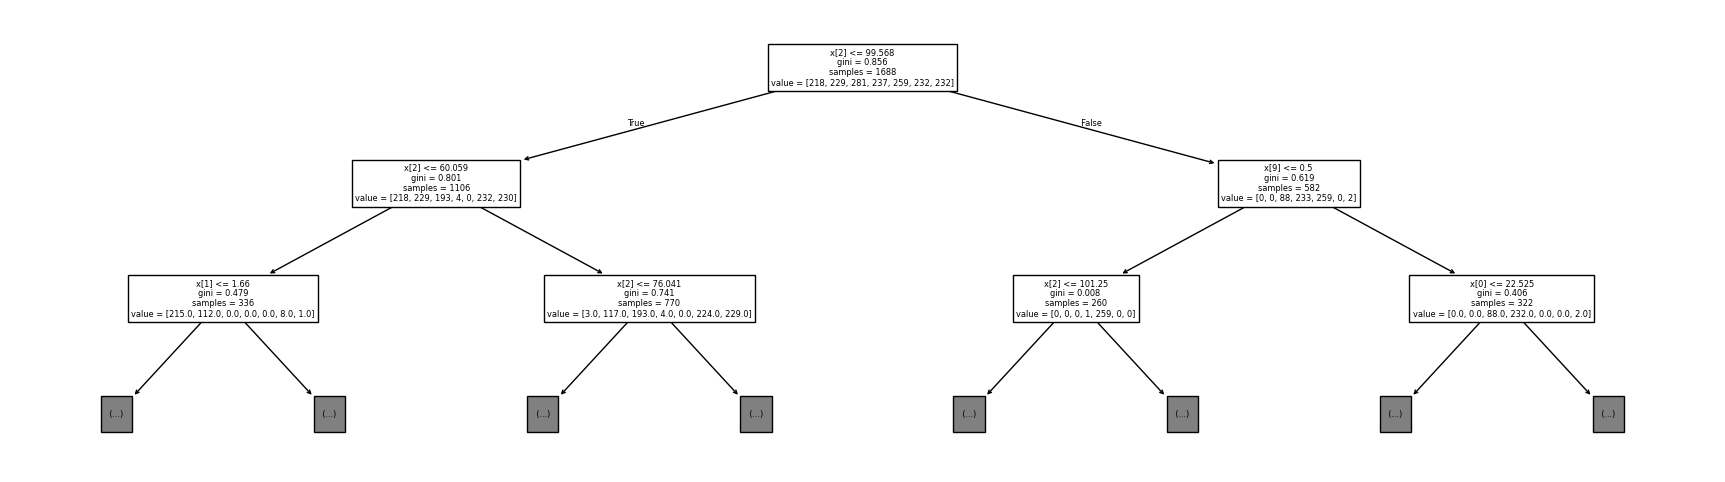

In [70]:
plt.figure(figsize = (22, 6))
plot_tree(model_tree, max_depth = 2)
plt.show()

# **Classification Report**

In [71]:
print(classification_report(obesity_labels_ts, model_tree.predict(obesity_features_ts)))

              precision    recall  f1-score   support

           0       0.96      0.87      0.91        54
           1       0.80      0.84      0.82        58
           2       0.91      0.96      0.93        70
           3       0.97      0.95      0.96        60
           4       1.00      0.98      0.99        65
           5       0.86      0.86      0.86        58
           6       0.91      0.91      0.91        58

    accuracy                           0.91       423
   macro avg       0.92      0.91      0.91       423
weighted avg       0.92      0.91      0.92       423



In [72]:
model_tree.classes_

array([0, 1, 2, 3, 4, 5, 6])

In [73]:
list(encoder.classes_)

['Insufficient_Weight',
 'Normal_Weight',
 'Obesity_Type_I',
 'Obesity_Type_II',
 'Obesity_Type_III',
 'Overweight_Level_I',
 'Overweight_Level_II']

# **Confusion Matrix**

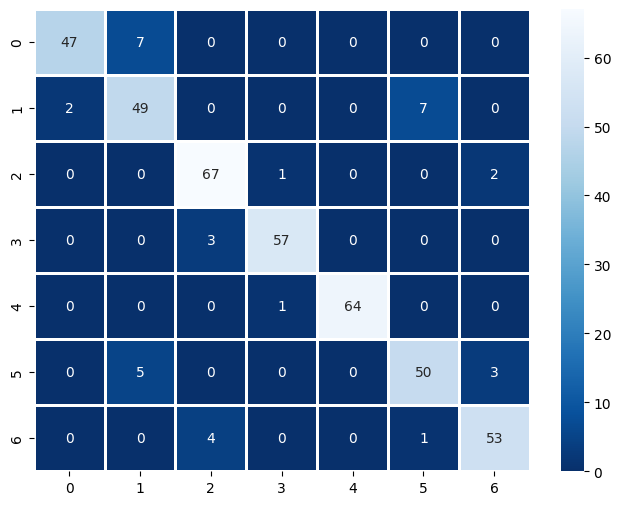

In [74]:
plt.figure(figsize = (8, 6))
sns.heatmap(confusion_matrix(obesity_labels_ts, model_tree.predict(obesity_features_ts)),
           annot = True,
           fmt = ".0f",
           cmap = "Blues_r",
           linewidths = 2,
           linecolor = "white",
           xticklabels = model_tree.classes_,
           yticklabels = model_tree.classes_)
plt.show()

# **ROC Score and Curve**

In [75]:
obesity_score_probability = model_tree.predict_proba(obesity_features_ts)

In [76]:
obesity_score_probability

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [77]:
roc_auc_score(obesity_labels_ts, obesity_score_probability, multi_class = "ovr")

0.948826099443833

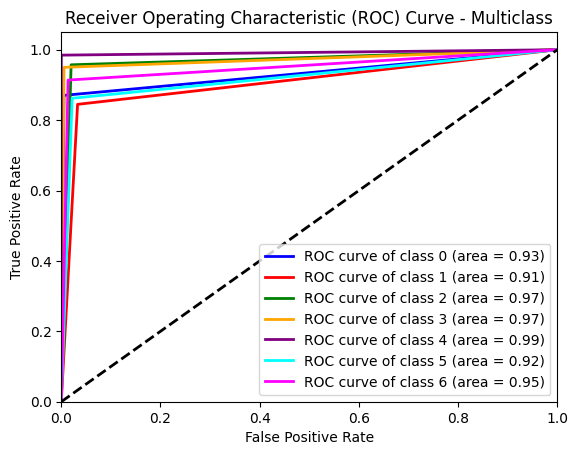

In [78]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels
y_test_bin = label_binarize(obesity_labels_ts, classes=model_tree.classes_)
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], obesity_score_probability[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure()
colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta']  # Adjust colors as needed
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(model_tree.classes_[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multiclass')
plt.legend(loc="lower right")
plt.show()


# **Clustering**

In [79]:
kmeans = KMeans(n_clusters = 7, init = "k-means++")

In [80]:
model_tree.feature_importances_

array([0.04184926, 0.22082785, 0.47515547, 0.0135702 , 0.00714488,
       0.00561014, 0.00081335, 0.01124707, 0.00060059, 0.15732823,
       0.0006524 , 0.00232294, 0.02176254, 0.00069194, 0.00134318,
       0.00157633, 0.00760256, 0.        , 0.        , 0.00135428,
       0.        , 0.        , 0.        , 0.        , 0.00062654,
       0.02540261, 0.00251765, 0.        , 0.        , 0.        ,
       0.        ])

In [81]:
def plot_clusters(dataset, feature_one, feature_two, labels, title = None):
    """
    Function: Computes and displays clusters.

    Parameters: dataset, 2 features, cluster indicator.
    """
    sns.scatterplot(data = dataset, x = feature_one, y = feature_two, hue = labels, palette = "Blues_r")
    if title is not None:
        plt.title(title)
    plt.show()

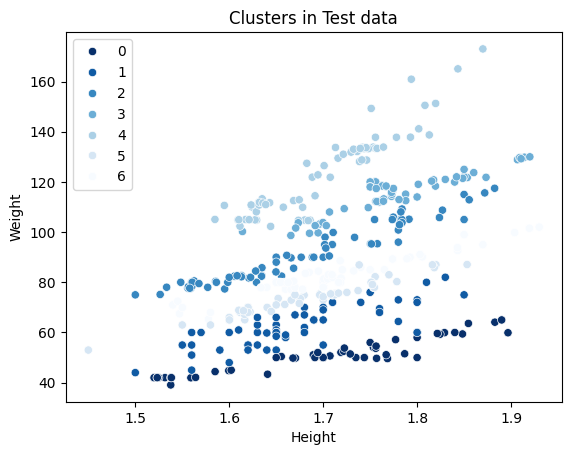

In [82]:
plot_clusters(obesity_features_ts, "Height", "Weight", obesity_labels_ts, "Clusters in Test data")

In [83]:
predicted_labels = kmeans.fit_predict(obesity_features_ts)

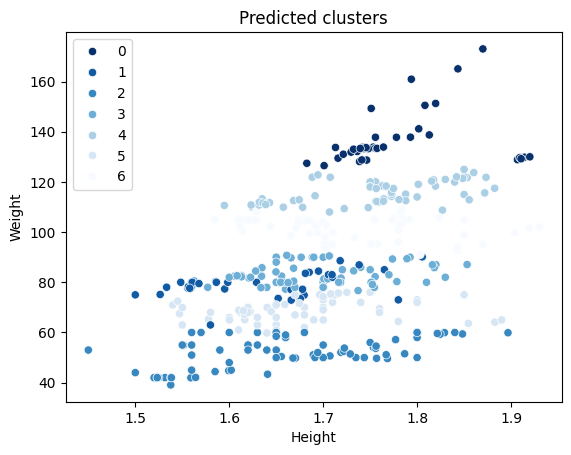

In [84]:
plot_clusters(obesity_features_ts, "Height", "Weight", predicted_labels, "Predicted clusters")

# **kesimpulan singkat**

In [85]:
def buat_kesimpulan(model, fitur_latih, label_latih, fitur_uji, label_uji, nama_fitur):

    # Hitung metrik kinerja
    akurasi_latih = accuracy_score(label_latih, model.predict(fitur_latih))
    f1_latih = f1_score(label_latih, model.predict(fitur_latih), average='weighted')
    akurasi_uji = accuracy_score(label_uji, model.predict(fitur_uji))
    f1_uji = f1_score(label_uji, model.predict(fitur_uji), average='weighted')
    roc_auc = roc_auc_score(label_uji, model.predict_proba(fitur_uji), multi_class='ovr')

    # Dapatkan tingkat kepentingan fitur
    tingkat_kepentingan_fitur = model.feature_importances_
    fitur_teratas = sorted(zip(nama_fitur, tingkat_kepentingan_fitur), key=lambda x: x[1], reverse=True)[:3]

    # Template kesimpulan
    kesimpulan = f"""
    Berdasarkan analisis, model pohon keputusan mencapai akurasi sebesar {akurasi_latih:.2f} pada data pelatihan dan {akurasi_uji:.2f} pada data pengujian.
    Nilai F1-score tertimbang adalah {f1_latih:.2f} untuk pelatihan dan {f1_uji:.2f} untuk pengujian.
    Skor ROC AUC adalah {roc_auc:.2f}, menunjukkan daya diskriminasi yang baik.
    Fitur yang paling penting untuk prediksi adalah {', '.join([f[0] for f in fitur_teratas])}.
    Hasil ini menunjukkan potensi pembelajaran mesin untuk prediksi obesitas dan menawarkan wawasan berharga untuk penelitian lebih lanjut.
    """

    return kesimpulan

# Dapatkan nama fitur (dengan asumsi obesity_features adalah DataFrame)
nama_fitur = obesity_features.columns.tolist()

# Buat kesimpulan
kesimpulan = buat_kesimpulan(model_tree, obesity_features_tr, obesity_labels_tr,
                                  obesity_features_ts, obesity_labels_ts, nama_fitur)

# Cetak kesimpulan
print(kesimpulan)


    Berdasarkan analisis, model pohon keputusan mencapai akurasi sebesar 1.00 pada data pelatihan dan 0.91 pada data pengujian. 
    Nilai F1-score tertimbang adalah 1.00 untuk pelatihan dan 0.92 untuk pengujian. 
    Skor ROC AUC adalah 0.95, menunjukkan daya diskriminasi yang baik. 
    Fitur yang paling penting untuk prediksi adalah Weight, Height, Gender_Male. 
    Hasil ini menunjukkan potensi pembelajaran mesin untuk prediksi obesitas dan menawarkan wawasan berharga untuk penelitian lebih lanjut.
    
